In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import scipy as stats
import seaborn as sns
import numpy as np
import platform

# 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False

# 출력 짤림 방지
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [14]:
# 데이터 불러오기
df = pd.read_csv('./data/Courses.csv', parse_dates=['start_time_DI', 'last_event_DI'])
df.head()


,index,course_id,userid_DI,registered,viewed,explored,certified,final_cc_cname_DI,LoE_DI,YoB,gender,grade,start_time_DI,last_event_DI,nevents,ndays_act,nplay_video,nchapters,nforum_posts,roles,incomplete_flag
0,0,HarvardX/CB22x/2013_Spring,MHxPC130442623,1,0,0,0,United States,NaN,NaN,NaN,0,2012-12-19,2013-11-17,NaN,9.0,NaN,NaN,0,NaN,1.0
1,1,HarvardX/CS50x/2012,MHxPC130442623,1,1,0,0,United States,NaN,NaN,NaN,0,2012-10-15,NaT,NaN,9.0,NaN,1.0,0,NaN,1.0
2,2,HarvardX/CB22x/2013_Spring,MHxPC130275857,1,0,0,0,United States,NaN,NaN,NaN,0,2013-02-08,2013-11-17,NaN,16.0,NaN,NaN,0,NaN,1.0
3,3,HarvardX/CS50x/2012,MHxPC130275857,1,0,0,0,United States,NaN,NaN,NaN,0,2012-09-17,NaT,NaN,16.0,NaN,NaN,0,NaN,1.0
4,4,HarvardX/ER22x/2013_Spring,MHxPC130275857,1,0,0,0,United States,NaN,NaN,NaN,0,2012-12-19,NaT,NaN,16.0,NaN,NaN,0,NaN,1.0


In [15]:
# 원본데이터 결측치 개수, 비율
display(pd.DataFrame({
    'sum': df.isna().sum(),
    'ratio': df.isna().mean() * 100
}).sort_values('ratio', ascending=False).reset_index())

,index,sum,ratio
0,roles,641138,100.000000
1,incomplete_flag,540977,84.377622
2,nplay_video,457530,71.362172
3,nchapters,258753,40.358394
4,nevents,199151,31.062111
5,last_event_DI,178954,27.911932
6,ndays_act,162743,25.383459
7,LoE_DI,106008,16.534350
8,YoB,96605,15.067739
9,gender,86806,13.539363


In [16]:
# 전처리용 데이터 셋 생성
pre = df.copy()

In [17]:
### 컬럼명 소문자화
pre.columns = pre.columns.str.lower()

In [18]:
# 중복행 확인
pre.duplicated().sum()

np.int64(0)

In [19]:
# 의미없는 컬럼 제거
pre = pre.drop(columns=['index', 'roles'])

In [20]:
#데이터 형변환
# grade 숫자형으로 변환
pre['grade'] = pd.to_numeric(pre['grade'], errors='coerce')

In [21]:
# 파생컬럼 생성

# 학생들의 나이(age) & (age_segment)
pre['age'] = pre['start_time_di'].dt.year - pre['yob']

pre['age_segment'] = np.select(
    [
        pre['age'].isna(),
        pre['age'] >= 60,
        pre['age'] >= 50,
        pre['age'] >= 40,
        pre['age'] >= 30,
        pre['age'] >= 20,
    ],
    [
        'unknown',
        '60s+',
        '50s',
        '40s',
        '30s',
        '20s',
    ],
    default='under 20'
)

# 퍼널 단계 컬럼(step): 각 학생 별 진행 단계
pre['step'] = np.select(
    [
        pre['certified'] ==1,
        pre['explored'] == 1,
        pre['viewed'] == 1,
        pre['registered'] == 1,
    ],
    [
        'c',
        'e',
        'v',
        'r'
    ],
    default='None'
)

# Missing Flag 컬럼 생성
missing_col = [
    'nchapters', 
    'nevents', 
    'ndays_act', 
    'nplay_video', 
    'last_event_di', 
    'age', 
    'grade']

for col in missing_col:
    pre[f'{col}_flag'] = pre[col].isna().astype(int)
    

# 학습 기간 (duration) 컬럼 생성 (같은 날일 경우 1)
pre['duration'] = ((pre['last_event_di'] - pre['start_time_di'])).dt.days.astype(int, errors='ignore') + 1

In [22]:
# 행제거
print('행 제거 작업 시작 전:')
print(pre.shape)

# 퍼널 논리적 오류 행 제거
funnel_mask1 = (pre['viewed'] == 0) & (pre['explored'] == 1)
funnel_mask2 = (pre['explored'] == 0) & (pre['certified'] == 1)
pre = pre[~funnel_mask1]
pre = pre[~funnel_mask2]

# durration 음수 행 제거
duration_mask = pre['duration'] <= 0
pre = pre[~duration_mask]

# age 13세 미만 행 제거
age_mask = pre['age'] < 13
pre = pre[~age_mask]

# 상시 개방된 강의 제거 
course_mask = (pre['course_id'] =='HarvardX/CS50x/2012') | (pre['course_id'] =='HarvardX/ER22x/2013_Spring') | (pre['course_id'] =='HarvardX/CB22x/2013_Spring')
pre = pre[~course_mask]

# incomplete_flag == 1 제외
pre = pre[pre['incomplete_flag'].isna()]

# 논리적 오류 drop 
rchap_mask = (pre['step']=='r') & ((pre['nchapters'] > 0) | (pre['nplay_video']>0))
pre = pre[~rchap_mask]

print('행 제거 작업 후:')
print(pre.shape)

행 제거 작업 시작 전:
(641138, 30)


C:\Users\gmltk\AppData\Local\Temp\ipykernel_549272\3461231621.py:9: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  pre = pre[~funnel_mask2]


행 제거 작업 후:
(354086, 30)


In [ ]:
# 결측치 대체

# 성별 결측치(gender) : unknown 대체
pre['gender'] = pre['gender'].fillna('unknown')

# 학력 결측치(LoE_DI) : unknown 대체
pre['loe_di'] = pre['loe_di'].fillna('unknown')

# 탐색한 챕터 수 결측치(nchapters) : registered 단계일 때 0으로 대체
pre.loc[
    (pre['step']=='r') & (pre['nchapters'].isna()),
    'nchapters'
] = 0

# 탐색한 챕터 수 결측치(nchapters) : viewed 단계일 때 2로 대체
v_nchapters_median = pre.loc[
    (pre['step']=='v') & (pre['nchapters'].notna()),
    'nchapters'
].median()

pre.loc[
    (pre['step']=='v') & (pre['nchapters'].isna()),
    'nchapters'
] = v_nchapters_median

# 총 이벤트 발생 수 결측치(nevent) : registered 단계일 때 0으로 대체
pre.loc[
    (pre['step']=='r') & (pre['nevents'].isna()),
    'nevents'
] = 0

# # 활성 일수 결측치(ndays_act) : 0으로 대체
pre['ndays_act'] = pre['ndays_act'].fillna(0)

# 영상재생횟수(nplay_video) 결측치
pre.loc[
    (pre['nchapters']==0) & (pre['nplay_video'].isna()),
    'nplay_video'
] = 0

# 영상재생횟수 Viewed 단계 결측치 중앙값으로 대체
v_play_median = pre.loc[
    (pre['step']=='v') & (pre['nplay_video'].notna()),
    'nplay_video'
].median()

pre.loc[
    (pre['step']=='v') & (pre['nplay_video'].isna()),
    'nplay_video'
] = v_play_median

# 영상재생횟수 Explored 단계 결측치 중앙값으로 대체
e_play_median = pre.loc[
    (pre['step']=='e') & (pre['nplay_video'].notna()),
    'nplay_video'
].median()

pre.loc[
    (pre['step']=='e') & (pre['nplay_video'].isna()),
    'nplay_video'
] = e_play_median

# 영상재생횟수 Certified 단계 결측치 중앙값으로 대체
c_play_median = pre.loc[
    (pre['step']=='c') & (pre['nplay_video'].notna()),
    'nplay_video'
].median()

pre.loc[
    (pre['step']=='c') & (pre['nplay_video'].isna()),
    'nplay_video'
] = c_play_median



# 마지막 이벤트 발생일 (last_event_DI) : 논의중

# 나이 (age) 결측치 : 논의중

# 성적(grade) 결측치 : 논의중

# 강좌내 활동 기간 (duration)
pre['duration'] = pre['duration'].fillna(0)


In [24]:
pre['duration'].value_counts().sort_index()

duration
1.0      109873
2.0       26329
3.0        5084
4.0        3689
5.0        3233
6.0        2911
7.0        2947
8.0        2825
9.0        2521
10.0       2151
11.0       2025
12.0       2084
13.0       2108
14.0       2148
15.0       2291
16.0       2049
17.0       1866
18.0       1736
19.0       1791
20.0       1902
21.0       1977
22.0       1865
23.0       1929
24.0       1680
25.0       1607
26.0       1612
27.0       1731
28.0       1783
29.0       1948
30.0       1763
31.0       1547
32.0       1603
33.0       1576
34.0       1533
35.0       1604
36.0       1664
37.0       1614
38.0       1418
39.0       1363
40.0       1332
41.0       1424
42.0       1457
43.0       1503
44.0       1436
45.0       1376
46.0       1308
47.0       1251
48.0       1259
49.0       1308
50.0       1361
51.0       1260
52.0       1198
53.0       1176
54.0       1212
55.0       1195
56.0       1225
57.0       1191
58.0       1129
59.0       1093
60.0       1072
61.0       1051
62.0       1057

In [ ]:
pre.isna().sum()

course_id                  0
userid_di                  0
registered                 0
viewed                     0
explored                   0
certified                  0
final_cc_cname_di          0
loe_di                     0
yob                    58670
gender                     0
grade                  37402
start_time_di              0
last_event_di          29858
nevents                 1768
ndays_act                  0
nplay_video                0
nchapters                  0
nforum_posts               0
incomplete_flag       354126
age                    58670
age_segment                0
step                       0
nchapters_flag             0
nevents_flag               0
ndays_act_flag             0
nplay_video_flag           0
last_event_di_flag         0
age_flag                   0
grade_flag                 0
duration                   0
dtype: int64

In [ ]:
pre.loc[
    (pre['step']=='r') &
    (pre['nchapters']>0)
].shape

(0, 30)

In [ ]:
# 강의별 공식 일정 테이블 생성 & merge

# 1. course_id별 공식 일정 매핑표
schedule_map = {
    # HarvardX
    'HarvardX/PH207x/2012_Fall': {
        'course_title': 'Health in Numbers: Quantitative Methods in Clinical & Public Health Research',
        'registration_open': '2012-07-24',
        'course_launch': '2012-10-15',
        'course_wrap': '2013-01-30'
    },
    'HarvardX/CS50x/2012': {
        'course_title': 'Introduction to Computer Science I',
        'registration_open': '2012-07-24',
        'course_launch': '2012-10-15',
                'course_wrap': '2013-04-15'
        },
        'HarvardX/HLS1x/2013_Spring': {
                'course_title': 'Copyright',
                'registration_open': '2012-12-19',
                'course_launch': '2013-01-28',
                'course_wrap': '2013-07-03'
        },
        'HarvardX/ER22x/2013_Spring': {
                'course_title': 'Justice',
                'registration_open': '2012-12-19',
                'course_launch': '2013-03-02',
                'course_wrap': '2013-07-26'
        },
        'HarvardX/CB22x/2013_Spring': {
                'course_title': 'The Ancient Greek Hero',
                'registration_open': '2012-12-19',
                'course_launch': '2013-03-13',
                'course_wrap': '2013-08-26'
        },
        'HarvardX/PH278x/2013_Spring': {
                'course_title': 'Human Health and Global Environmental Change',
                'registration_open': '2012-12-19',
                'course_launch': '2013-05-15',
                'course_wrap': '2013-07-25'
        },

        # MITx
        'MITx/6.002x/2012_Fall': {
                'course_title': 'Circuits and Electronics - Fall',
                'registration_open': '2012-07-24',
                'course_launch': '2012-09-05',
                'course_wrap': '2012-12-25'
        },
        'MITx/6.00x/2012_Fall': {
                'course_title': 'Introduction to Computer Science and Programming - Fall',
                'registration_open': '2012-07-24',
                'course_launch': '2012-09-26',
                'course_wrap': '2013-01-15'
        },
        'MITx/3.091x/2012_Fall': {
                'course_title': 'Introduction to Solid State Chemistry - Fall',
                'registration_open': '2012-07-24',
                'course_launch': '2012-10-09',
                'course_wrap': '2013-01-15'
        },
        'MITx/6.00x/2013_Spring': {
                'course_title': 'Introduction to Computer Science and Programming - Spring',
                'registration_open': '2012-12-19',
                'course_launch': '2013-02-04',
                'course_wrap': '2013-06-04'
        },
        'MITx/3.091x/2013_Spring': {
                'course_title': 'Introduction to Solid State Chemistry - Spring',
                'registration_open': '2012-12-20',
                'course_launch': '2013-02-05',
                'course_wrap': '2013-06-21'
        },
        'MITx/14.73x/2013_Spring': {
                'course_title': 'The Challenges of Global Poverty',
                'registration_open': '2012-12-19',
                'course_launch': '2013-02-12',
                'course_wrap': '2013-05-21'
        },
        'MITx/8.02x/2013_Spring': {
                'course_title': 'Electricity and Magnetism',
                'registration_open': '2013-01-17',
                'course_launch': '2013-02-18',
                'course_wrap': '2013-06-18'
        },
        'MITx/6.002x/2013_Spring': {
                'course_title': 'Circuits and Electronics - Spring',
                'registration_open': '2012-12-20',
                'course_launch': '2013-03-03',
                'course_wrap': '2013-07-01'
        },
        'MITx/7.00x/2013_Spring': {
                'course_title': 'Introduction to Biology - The Secret of Life',
                'registration_open': '2013-01-30',
                'course_launch': '2013-03-05',
                'course_wrap': '2013-06-06'
        },
        'MITx/2.01x/2013_Spring': {
                'course_title': 'Elements of Structures',
                'registration_open': '2013-02-24',
                'course_launch': '2013-04-15',
                'course_wrap': '2013-07-30'
        },
        'MITx/8.MReV/2013_Summer': {
                'course_title': 'Mechanics ReView',
                'registration_open': '2013-04-27',
                'course_launch': '2013-06-01',
                'course_wrap': '2013-09-15'
        }
}

# 2. dict -> DataFrame 변환
schedule_df = (
        pd.DataFrame(schedule_map)
        .T
        .reset_index()
        .rename(columns={'index': 'course_id'})
)

# 3. 날짜형 변환
date_cols = ['registration_open', 'course_launch', 'course_wrap']
for col in date_cols:
        schedule_df[col] = pd.to_datetime(schedule_df[col])

# pre = pd.merge()

In [ ]:
display(schedule_df)

,course_id,course_title,registration_open,course_launch,course_wrap
0,HarvardX/PH207x/2012_Fall,Health in Numbers: Quantitative Methods in Cli...,2012-07-24,2012-10-15,2013-01-30
1,HarvardX/CS50x/2012,Introduction to Computer Science I,2012-07-24,2012-10-15,2013-04-15
2,HarvardX/HLS1x/2013_Spring,Copyright,2012-12-19,2013-01-28,2013-07-03
3,HarvardX/ER22x/2013_Spring,Justice,2012-12-19,2013-03-02,2013-07-26
4,HarvardX/CB22x/2013_Spring,The Ancient Greek Hero,2012-12-19,2013-03-13,2013-08-26
5,HarvardX/PH278x/2013_Spring,Human Health and Global Environmental Change,2012-12-19,2013-05-15,2013-07-25
6,MITx/6.002x/2012_Fall,Circuits and Electronics - Fall,2012-07-24,2012-09-05,2012-12-25
7,MITx/6.00x/2012_Fall,Introduction to Computer Science and Programmi...,2012-07-24,2012-09-26,2013-01-15
8,MITx/3.091x/2012_Fall,Introduction to Solid State Chemistry - Fall,2012-07-24,2012-10-09,2013-01-15
9,MITx/6.00x/2013_Spring,Introduction to Computer Science and Programmi...,2012-12-19,2013-02-04,2013-06-04


In [ ]:
# 2차 컬럼 drop
pre = pre.drop(columns=['yob', 'incomplete_flag'])

In [ ]:
pre.loc[
    (pre['nchapters']==0) & pre['nplay_video'].isna()
].shape

(0, 28)

<Axes: >

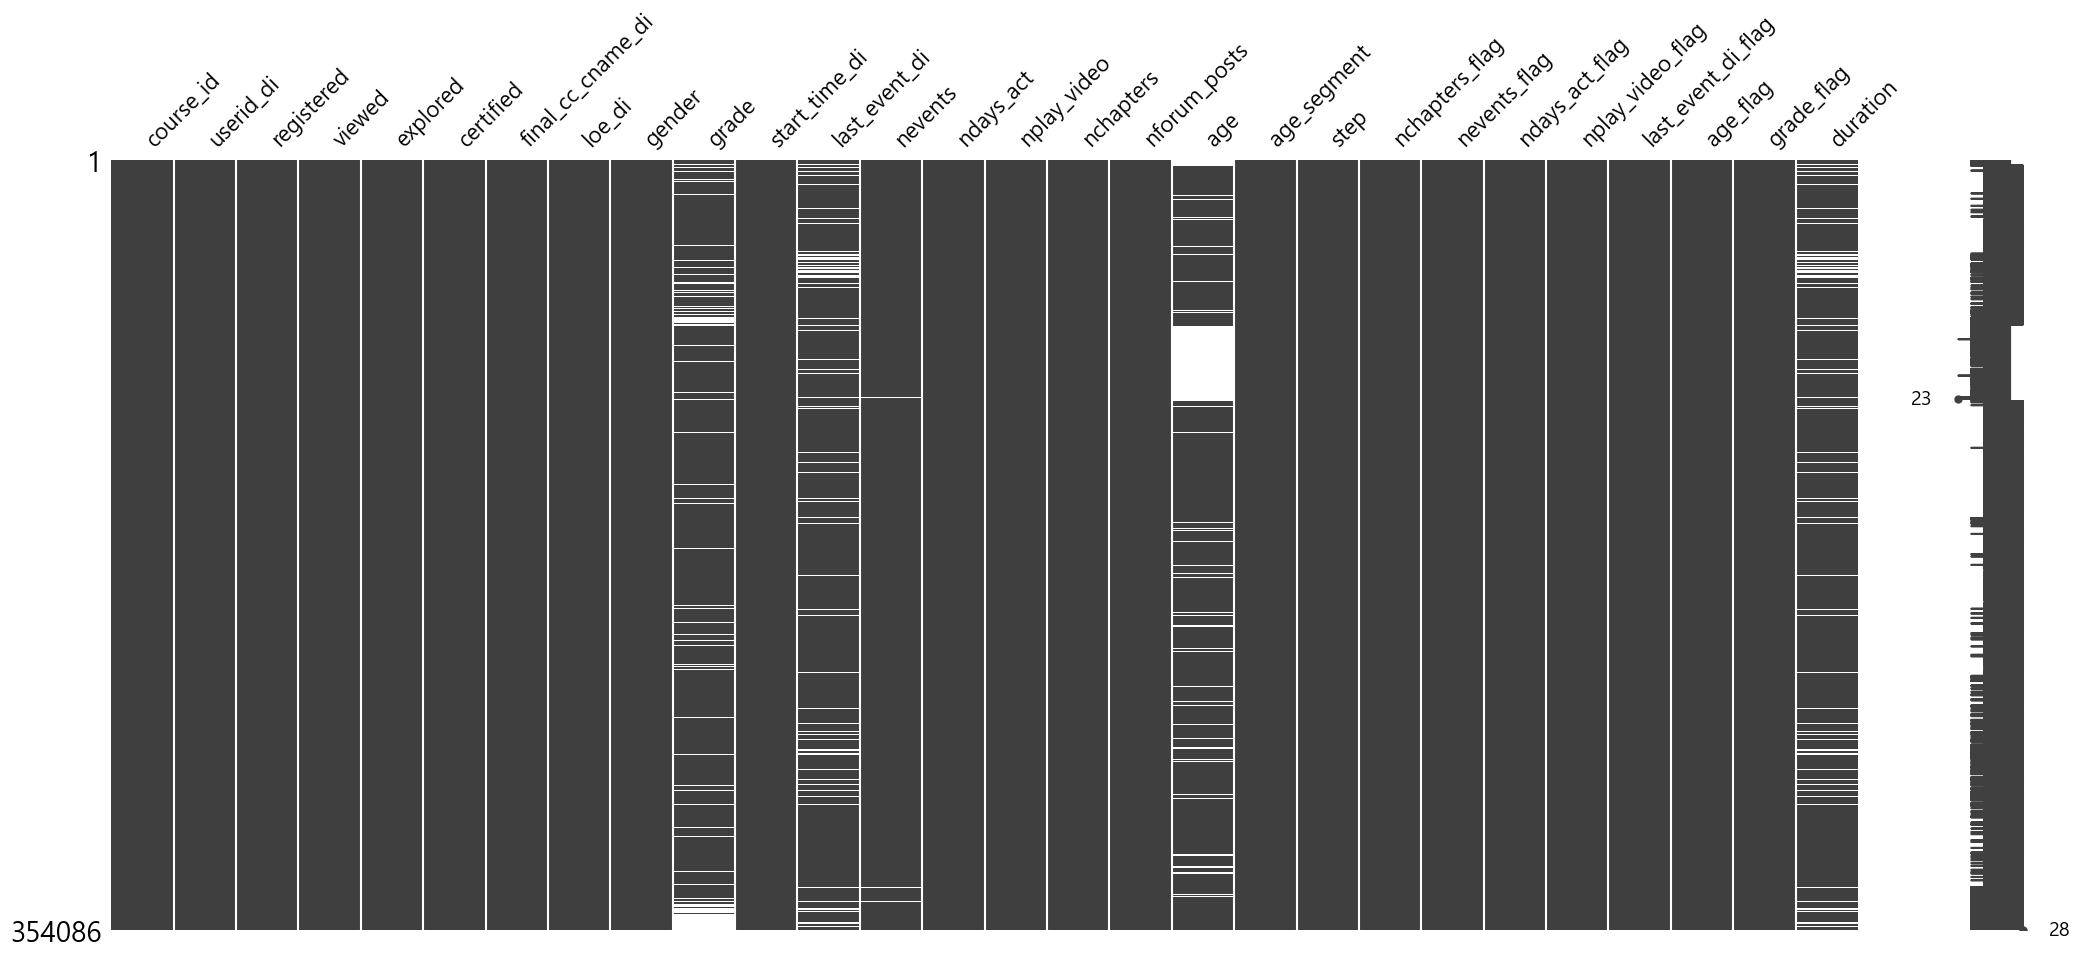

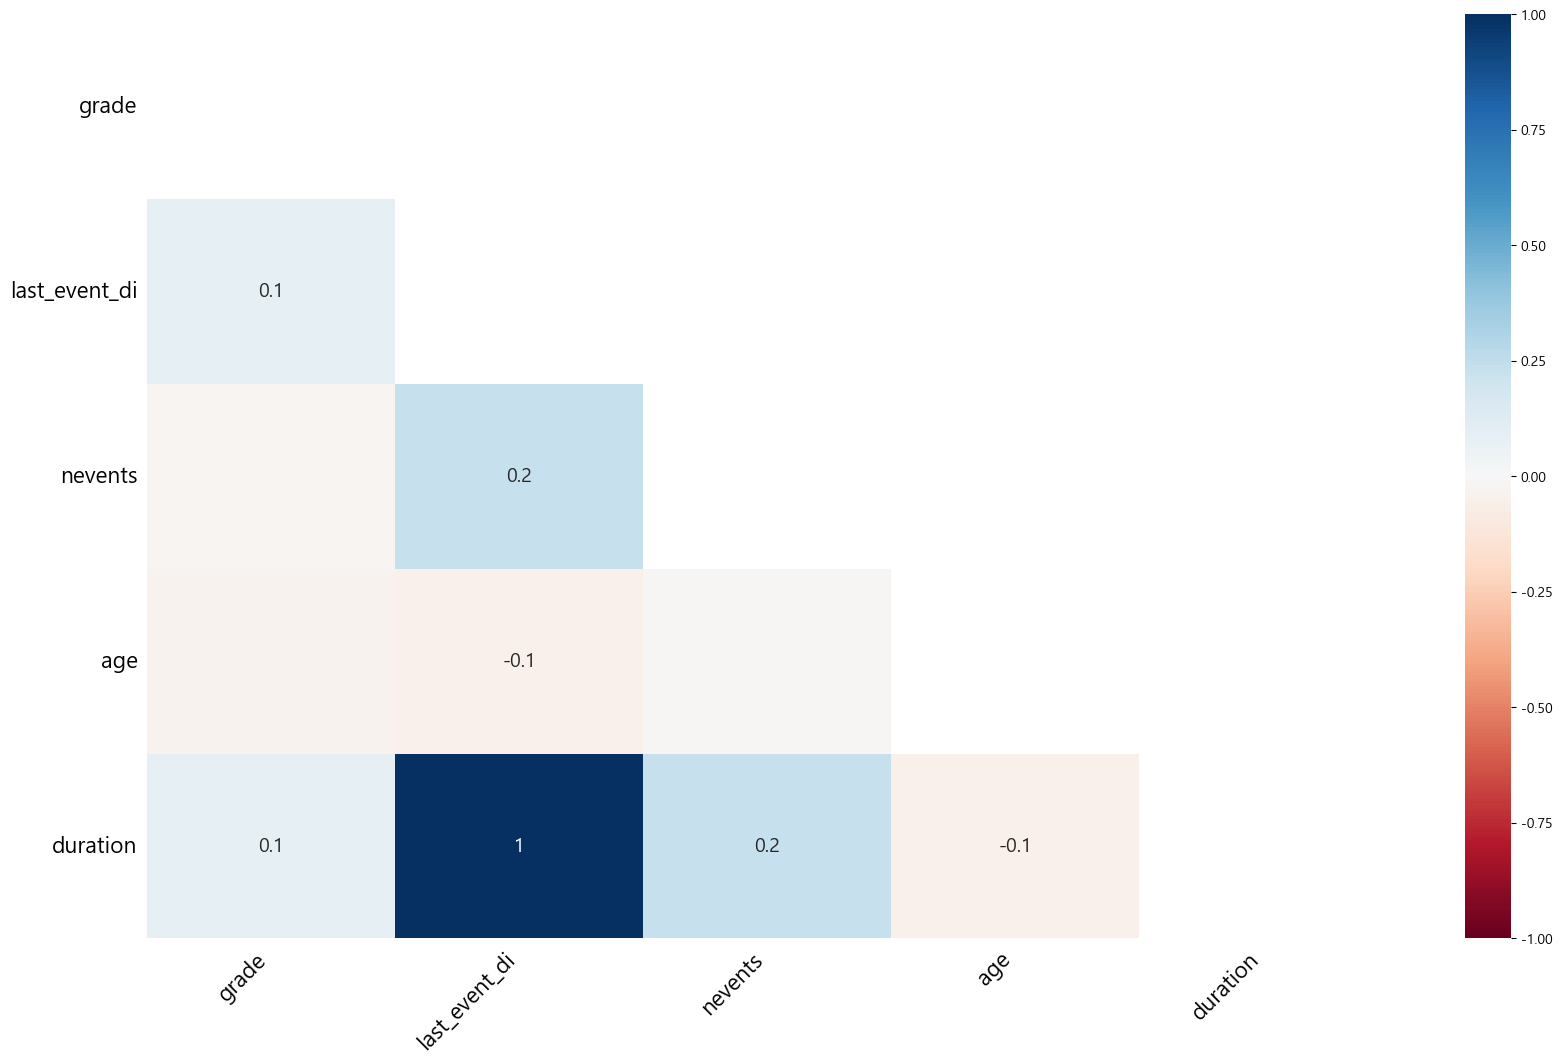

In [ ]:
import missingno as msno
msno.matrix(pre)
msno.heatmap(pre)

In [ ]:
pre[pre['grade'] == 0].notna().sum()

course_id             252148
userid_di             252148
registered            252148
viewed                252148
explored              252148
certified             252148
final_cc_cname_di     252148
loe_di                252148
gender                252148
grade                 252148
start_time_di         252148
last_event_di         228081
nevents               250398
ndays_act             252148
nplay_video           252148
nchapters             252148
nforum_posts          252148
age                   211660
age_segment           252148
step                  252148
nchapters_flag        252148
nevents_flag          252148
ndays_act_flag        252148
nplay_video_flag      252148
last_event_di_flag    252148
age_flag              252148
grade_flag            252148
duration              228081
dtype: int64

In [ ]:
pre[pre['grade'].isna()].notna().sum()

course_id             37396
userid_di             37396
registered            37396
viewed                37396
explored              37396
certified             37396
final_cc_cname_di     37396
loe_di                37396
gender                37396
grade                     0
start_time_di         37396
last_event_di         31609
nevents               37381
ndays_act             37396
nplay_video           37396
nchapters             37396
nforum_posts          37396
age                   32691
age_segment           37396
step                  37396
nchapters_flag        37396
nevents_flag          37396
ndays_act_flag        37396
nplay_video_flag      37396
last_event_di_flag    37396
age_flag              37396
grade_flag            37396
duration              31609
dtype: int64

<Axes: >

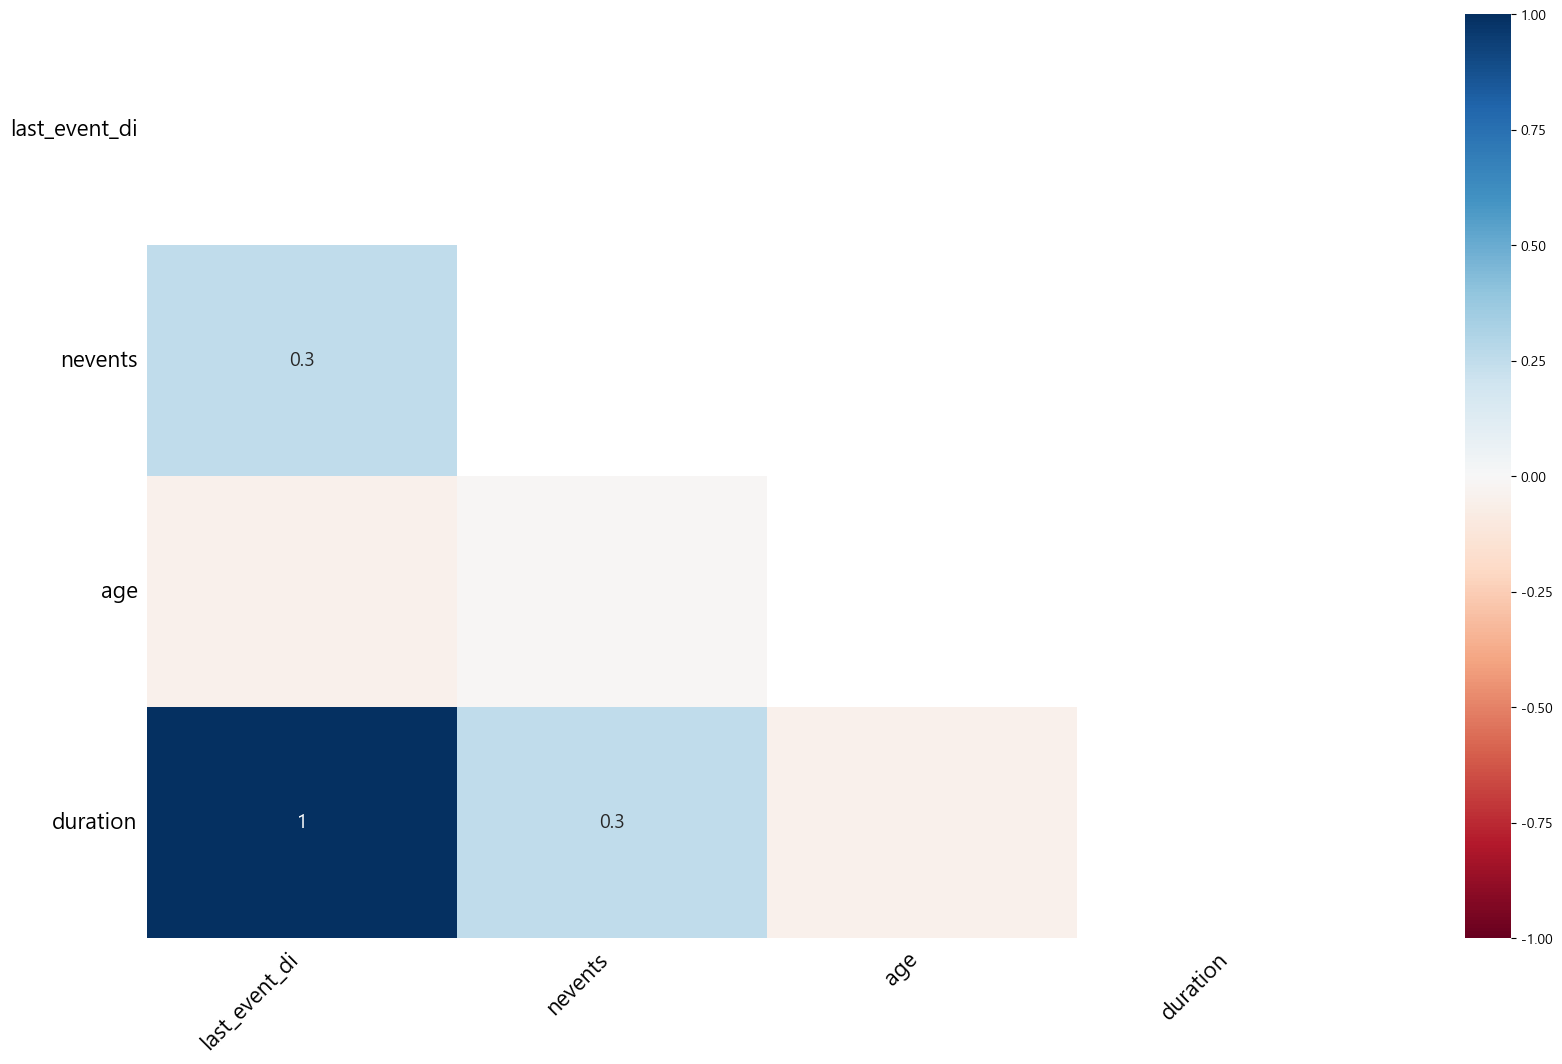

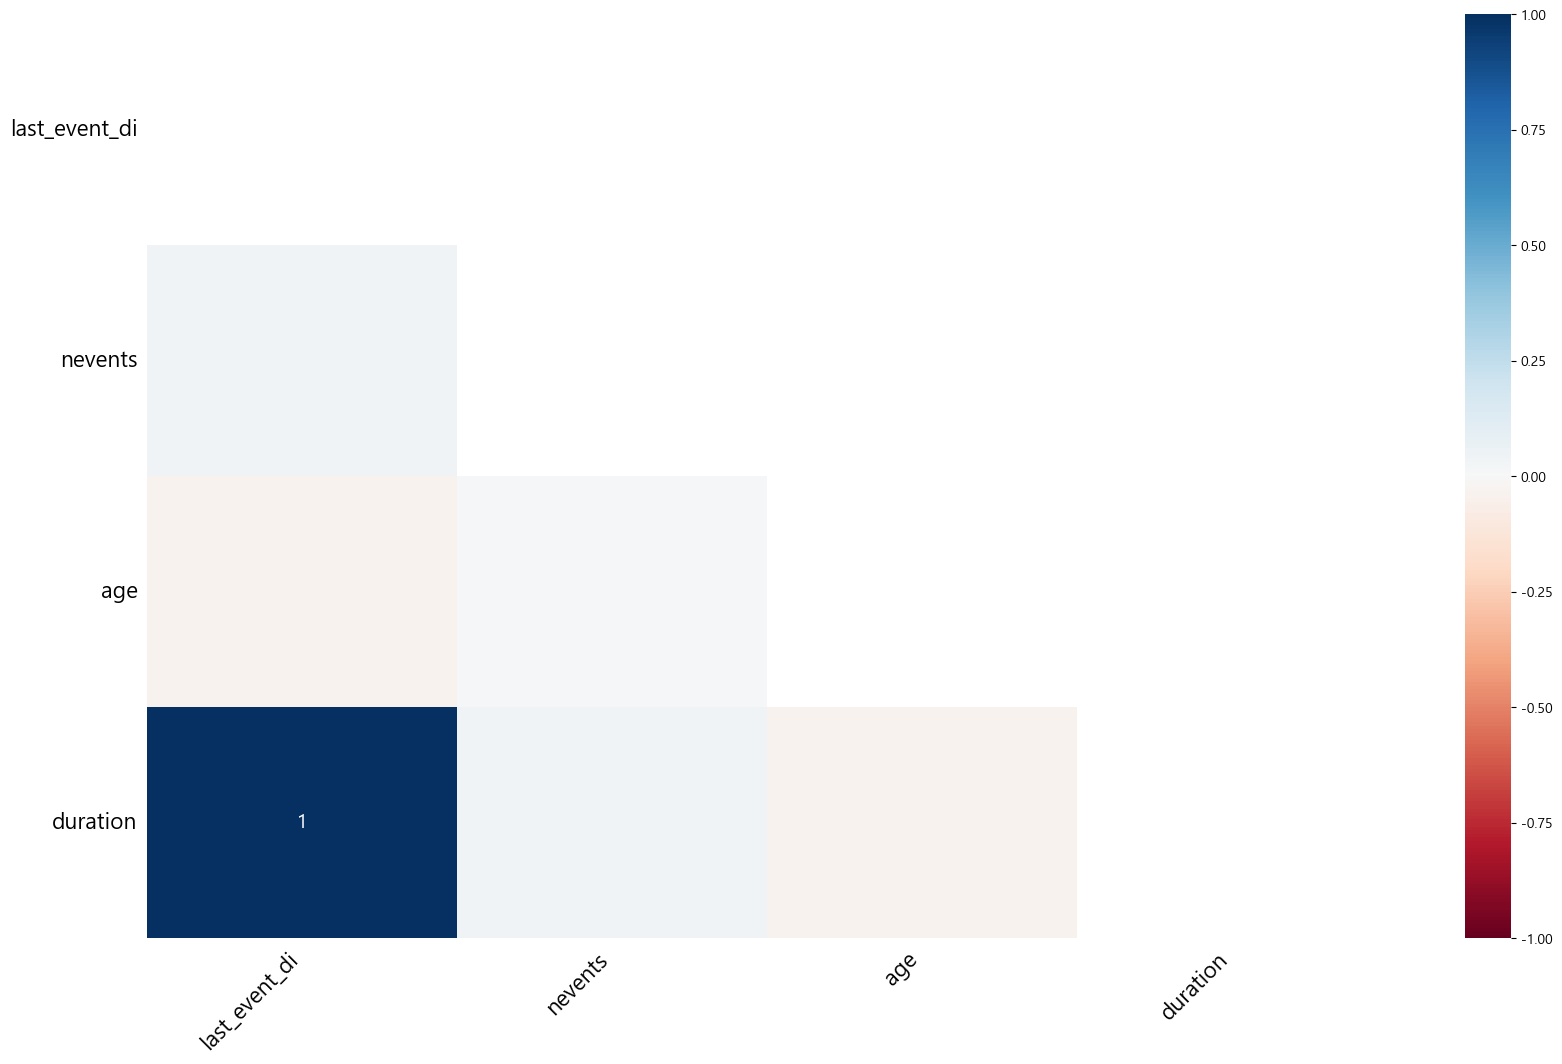

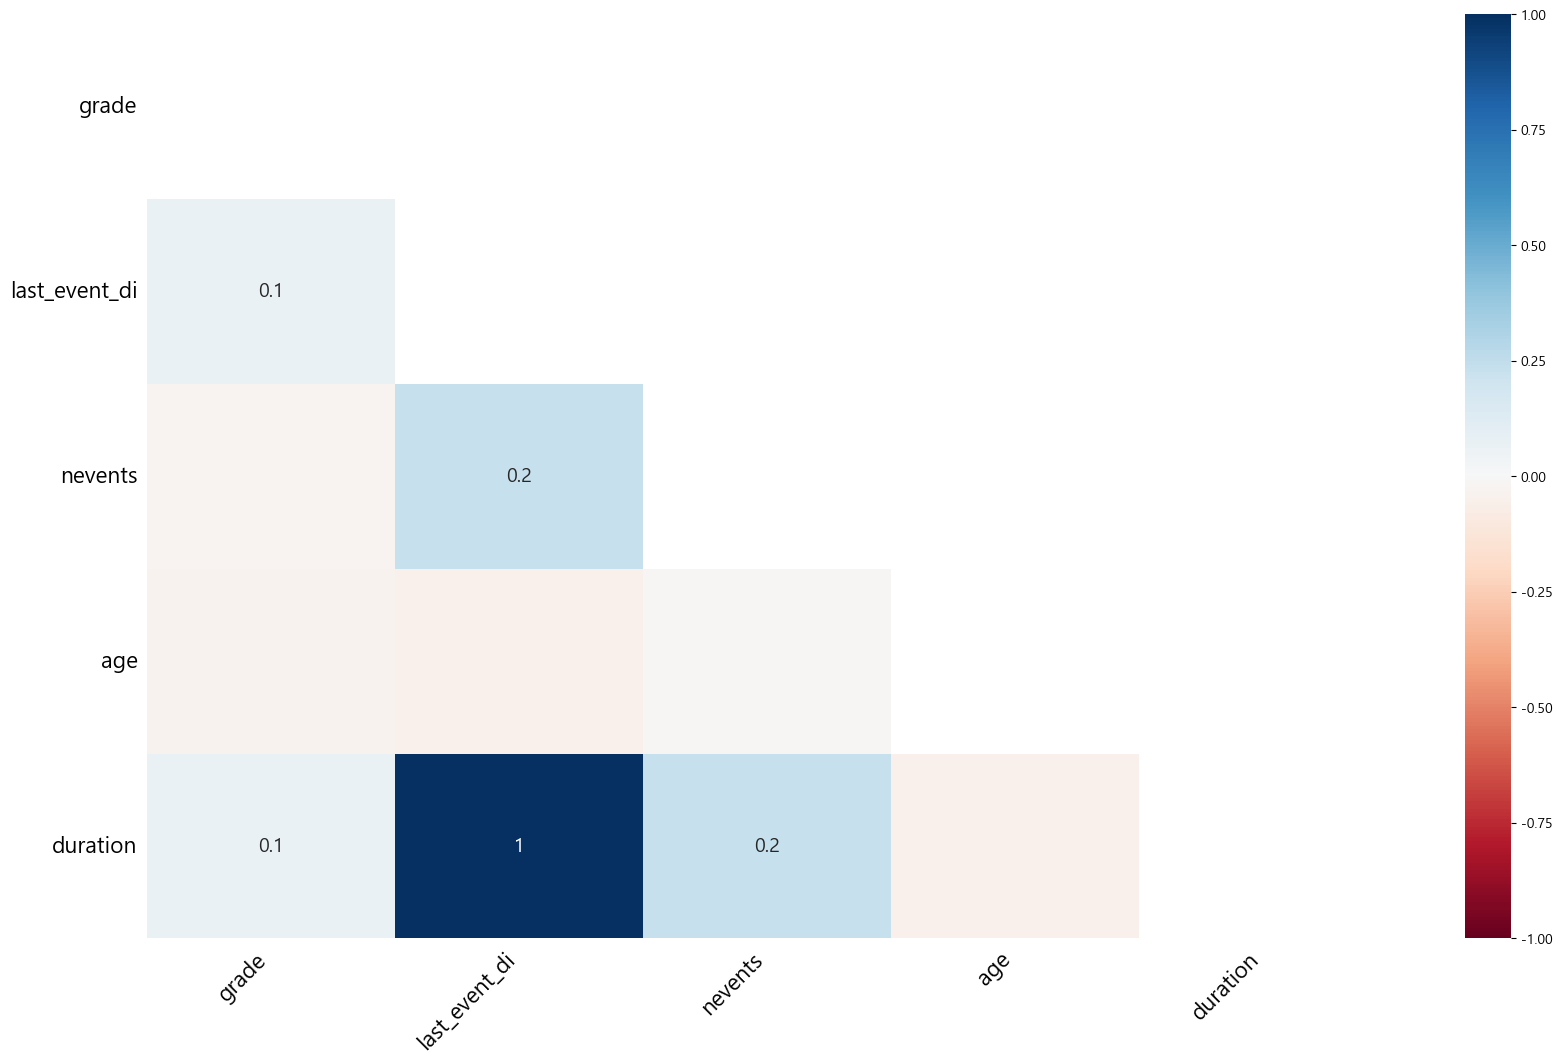

In [ ]:
temp1 = pre[pre['grade']==0]
temp2 = pre[pre['grade'].isna()]
temp3 = pre[
    (pre['grade']==0) |
    (pre['grade'].isna())
]


msno.heatmap(temp1)
msno.heatmap(temp2)
msno.heatmap(temp3)


In [ ]:
pre.groupby('course_id')[['nchapters', 'nevents']].apply(lambda x: x.isna().sum())

,nchapters,nevents
course_id,,
HarvardX/PH207x/2012_Fall,0,0
HarvardX/PH278x/2013_Spring,0,0
MITx/14.73x/2013_Spring,0,18
MITx/2.01x/2013_Spring,0,0
MITx/3.091x/2012_Fall,0,0
MITx/3.091x/2013_Spring,0,190
MITx/6.002x/2012_Fall,0,115
MITx/6.002x/2013_Spring,0,0
MITx/6.00x/2012_Fall,0,1


In [ ]:
tmp = pre.groupby('course_id').apply(lambda x: x.isna().mean())
tmp[['last_event_di', 'ndays_act', 'nevents', 'nchapters']]

,last_event_di,ndays_act,nevents,nchapters
course_id,,,,
HarvardX/PH207x/2012_Fall,0.083067,0.0,0.000000,0.0
HarvardX/PH278x/2013_Spring,0.265624,0.0,0.000000,0.0
MITx/14.73x/2013_Spring,0.103352,0.0,0.000718,0.0
MITx/2.01x/2013_Spring,0.023805,0.0,0.000000,0.0
MITx/3.091x/2012_Fall,0.052560,0.0,0.000000,0.0
MITx/3.091x/2013_Spring,0.045944,0.0,0.035924,0.0
MITx/6.002x/2012_Fall,0.051342,0.0,0.002978,0.0
MITx/6.002x/2013_Spring,0.067972,0.0,0.000000,0.0
MITx/6.00x/2012_Fall,0.058416,0.0,0.000015,0.0


In [ ]:
pre.groupby('course_id').size()


course_id
HarvardX/PH207x/2012_Fall      40979
HarvardX/PH278x/2013_Spring    35283
MITx/14.73x/2013_Spring        25060
MITx/2.01x/2013_Spring          5503
MITx/3.091x/2012_Fall          13889
MITx/3.091x/2013_Spring         5289
MITx/6.002x/2012_Fall          38623
MITx/6.002x/2013_Spring        19199
MITx/6.00x/2012_Fall           65804
MITx/6.00x/2013_Spring         50503
MITx/7.00x/2013_Spring         19446
MITx/8.02x/2013_Spring         25738
MITx/8.MReV/2013_Summer         8770
dtype: int64

In [ ]:
pre.groupby('course_id')['certified'].mean()

course_id
HarvardX/PH207x/2012_Fall      0.044877
HarvardX/PH278x/2013_Spring    0.018054
MITx/14.73x/2013_Spring        0.082801
MITx/2.01x/2013_Spring         0.044703
MITx/3.091x/2012_Fall          0.045504
MITx/3.091x/2013_Spring        0.020231
MITx/6.002x/2012_Fall          0.044870
MITx/6.002x/2013_Spring        0.029793
MITx/6.00x/2012_Fall           0.037186
MITx/6.00x/2013_Spring         0.024791
MITx/7.00x/2013_Spring         0.041037
MITx/8.02x/2013_Spring         0.031898
MITx/8.MReV/2013_Summer        0.030445
Name: certified, dtype: float64

In [ ]:
pre[
    (pre['nchapters'].isna())&
    (pre['certified'] == 1)
].shape


(0, 28)

In [ ]:
pre.groupby('course_id')[['nchapters', 'nevents']].apply(lambda x: x.isna().mean())

,nchapters,nevents
course_id,,
HarvardX/PH207x/2012_Fall,0.0,0.000000
HarvardX/PH278x/2013_Spring,0.0,0.000000
MITx/14.73x/2013_Spring,0.0,0.000718
MITx/2.01x/2013_Spring,0.0,0.000000
MITx/3.091x/2012_Fall,0.0,0.000000
MITx/3.091x/2013_Spring,0.0,0.035924
MITx/6.002x/2012_Fall,0.0,0.002978
MITx/6.002x/2013_Spring,0.0,0.000000
MITx/6.00x/2012_Fall,0.0,0.000015


In [ ]:
# pre['year_month'] = pre['start_time_di'].dt.to_period('M')

# missing_trend = pre.groupby('year_month')['nchapters'].apply(lambda x: x.isna().mean().mean())

# missing_trend.plot(figsize=(12,5), marker='o')
# plt.title("시기별 결측 비율 추이")
# plt.ylabel("Missing Ratio")
# plt.xlabel("Time")
# plt.grid()
# plt.show()

In [ ]:
missing_by_course = (
    pre.groupby('course_id')
       .apply(lambda x: x.isna().mean())
       .reset_index()
)

missing_by_course.head()

,course_id,userid_di,registered,viewed,explored,certified,final_cc_cname_di,loe_di,gender,grade,start_time_di,last_event_di,nevents,ndays_act,nplay_video,nchapters,nforum_posts,age,age_segment,step,nchapters_flag,nevents_flag,ndays_act_flag,nplay_video_flag,last_event_di_flag,age_flag,grade_flag,duration
0,HarvardX/PH207x/2012_Fall,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.136655,0.0,0.083067,0.000000,0.0,0.0,0.0,0.0,0.078577,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.083067
1,HarvardX/PH278x/2013_Spring,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.178726,0.0,0.265624,0.000000,0.0,0.0,0.0,0.0,0.087408,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.265624
2,MITx/14.73x/2013_Spring,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.061133,0.0,0.103352,0.000718,0.0,0.0,0.0,0.0,0.112769,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.103352
3,MITx/2.01x/2013_Spring,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.085226,0.0,0.023805,0.000000,0.0,0.0,0.0,0.0,0.252408,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.023805
4,MITx/3.091x/2012_Fall,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.068759,0.0,0.052560,0.000000,0.0,0.0,0.0,0.0,0.192886,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.052560


In [ ]:
pre[
    (pre['nevents'].isna())&
    (pre['ndays_act']==0)
].head(20)

,course_id,userid_di,registered,viewed,explored,certified,final_cc_cname_di,loe_di,gender,grade,start_time_di,last_event_di,nevents,ndays_act,nplay_video,nchapters,nforum_posts,age,age_segment,step,nchapters_flag,nevents_flag,ndays_act_flag,nplay_video_flag,last_event_di_flag,age_flag,grade_flag,duration
338496,MITx/6.002x/2012_Fall,MHxPC130234401,1,1,0,0,Other Africa,unknown,unknown,0.0,2012-09-07,NaT,NaN,0.0,14.0,2.0,0,NaN,unknown,v,1,1,1,1,1,1,0,NaN
338779,MITx/6.002x/2012_Fall,MHxPC130264142,1,1,0,0,Unknown/Other,unknown,unknown,0.0,2012-09-07,NaT,NaN,0.0,14.0,2.0,0,NaN,unknown,v,1,1,1,1,1,1,0,NaN
339133,MITx/6.002x/2012_Fall,MHxPC130301095,1,1,0,0,Pakistan,unknown,unknown,0.0,2012-09-07,NaT,NaN,0.0,14.0,2.0,0,NaN,unknown,v,1,1,1,1,1,1,0,NaN
339205,MITx/6.00x/2013_Spring,MHxPC130199464,1,1,0,0,United States,unknown,unknown,0.0,2013-02-06,NaT,NaN,0.0,14.0,2.0,0,NaN,unknown,v,1,1,1,1,1,1,0,NaN
339338,MITx/6.00x/2013_Spring,MHxPC130125722,1,1,0,0,Unknown/Other,unknown,unknown,0.0,2012-12-23,NaT,NaN,0.0,14.0,2.0,0,NaN,unknown,v,1,1,1,1,1,1,0,NaN
340370,MITx/6.00x/2013_Spring,MHxPC130306970,1,1,0,0,Other South Asia,unknown,unknown,0.0,2013-02-15,NaT,NaN,0.0,14.0,2.0,0,NaN,unknown,v,1,1,1,1,1,1,0,NaN
341077,MITx/3.091x/2013_Spring,MHxPC130149275,1,1,0,0,India,unknown,unknown,0.0,2012-12-20,NaT,NaN,0.0,14.0,2.0,0,NaN,unknown,v,1,1,1,1,1,1,0,NaN
341089,MITx/6.00x/2013_Spring,MHxPC130062283,1,1,0,0,United Kingdom,unknown,unknown,0.0,2013-03-01,NaT,NaN,0.0,14.0,2.0,0,NaN,unknown,v,1,1,1,1,1,1,0,NaN
341105,MITx/3.091x/2013_Spring,MHxPC130077738,1,1,0,0,Canada,unknown,unknown,0.0,2013-02-20,NaT,NaN,0.0,14.0,2.0,0,NaN,unknown,v,1,1,1,1,1,1,0,NaN
341558,MITx/6.00x/2013_Spring,MHxPC130402324,1,1,0,0,United States,unknown,unknown,0.0,2013-02-06,NaT,NaN,0.0,14.0,2.0,0,NaN,unknown,v,1,1,1,1,1,1,0,NaN


In [ ]:
pre[
    (pre['step'] == 'Viewed') &
    (pre['ndays_act'] == 0)
].shape

(0, 28)

In [ ]:
df[
    (df['viewed'] ==1)&
    (df['explored']==0) &
    (df['certified']==0)&
    (df['nchapters'].isna())&
    (df['incomplete_flag'].isna())
].shape

(17847, 21)

In [ ]:
pre['gender'].value_counts()

gender
m          225459
f           74938
unknown     53689
Name: count, dtype: int64

In [ ]:
pre[
    (pre['ndays_act'].isna())&
    (pre['last_event_di'].notna())
].shape

(0, 28)